# LIDAR vs MintPy

This workflow masks and subsets the MintPy timeseries, subsets `geometryGeo.h5`, projects the LIDAR field into InSAR LOS, and then computes correlations against MintPy displacement slices.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from mintpy.cli import generate_mask, mask as mintpy_mask, subset, view
from mintpy.utils import utils as ut

from snowsar.utils.lidar_utils import (
    compute_pearson_correlation,
    cumulative_sum_through_date,
    list_hdf5_root_datasets,
    local_incidence_from_geometry,
    mintpy_date_from_slice_name,
    mintpy_date_slice_names,
    project_scalar_field_to_los,
    resample_geometry_dataset_to_raster,
    subset_geotiff_by_bbox,
)


In [ ]:
NOTEBOOK_DIR = Path.cwd() / "LIDAR_notebooks" if (Path.cwd() / "LIDAR_notebooks").exists() else Path.cwd()
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILE = Path("/Volumes/Fortress_L3/SnowWaterEquivalent/ALOS2_CA_P67_F750_A/CA_P67_F750_A_Dec22_June23/mintpy/geo/geo_timeseries_demErr.h5")
GEOMETRY_FILE = Path("/Volumes/Fortress_L3/SnowWaterEquivalent/ALOS2_CA_P67_F750_A/CA_P67_F750_A_Dec22_June23/mintpy/geo/geo_geometryRadar.h5")
LIDAR_FILE = Path("/Volumes/Fortress_L3/SnowWaterEquivalent/LIDAR_notebooks_new/outputs/resampled/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006.tif")
TARGET_DATE = "20230406"
CUMULATIVE_END_DATE = "20230406"

# TIMESERIES_FILE = Path("/Volumes/Fortress_L3/SnowWaterEquivalent/ALOS2_CA_P67_F750_A/CA_P67_F750_A_Dec21_June22/mintpy/geo/geo_timeseries_ERA5_demErr.h5")
# GEOMETRY_FILE = Path("/Volumes/Fortress_L3/SnowWaterEquivalent/ALOS2_CA_P67_F750_A/CA_P67_F750_A_Dec21_June22/mintpy/geo/geo_geometryRadar.h5")
# LIDAR_FILE = Path("/Users/havazli/snowsar/LIDAR_notebooks/outputs_2022/resampled/resampled_ASO_Truckee_Mosaic_2022Apr8-9_snowdepth_3m-003.tif")
# TARGET_DATE = "20220407"
# CUMULATIVE_END_DATE = "20220407"

LIDAR_PRODUCT_NAME = "snow_depth"
LIDAR_DIRECTION = "vertical"  # "surface_normal" or "vertical"
MASK_SHADOW = False

SUBSET_LAT = (38.68, 39.65)
SUBSET_LON = (-120.50, -119.78)

DISPLACEMENT_SCALE_CM = 1

for path in (TIMESERIES_FILE, GEOMETRY_FILE, LIDAR_FILE):
    if not path.exists():
        raise FileNotFoundError(f"Update the config cell. Missing input: {path}")

LIDAR_MASK_FILE = OUTPUT_DIR / f"{LIDAR_FILE.stem}_mask.h5"
MASKED_TIMESERIES_FILE = OUTPUT_DIR / f"{TIMESERIES_FILE.stem}_masked.h5"
SUBSET_TIMESERIES_FILE = OUTPUT_DIR / f"{TIMESERIES_FILE.stem}_masked_subset.h5"
SUBSET_GEOMETRY_FILE = OUTPUT_DIR / f"{GEOMETRY_FILE.stem}_subset.h5"
SUBSET_LIDAR_FILE = OUTPUT_DIR / f"{LIDAR_FILE.stem}_subset{LIDAR_FILE.suffix}"


FileNotFoundError: Update the config cell. Missing input: /Volumes/Fortress_L3/SnowWaterEquivalent/ALOS2_CA_P67_F750_A/CA_P67_F750_A_Dec22_June23/mintpy/geo/geo_timeseries_demErr.h5

## Generate mask and subset products

In [3]:
generate_mask.main([str(LIDAR_FILE), "-o", str(LIDAR_MASK_FILE)])
mintpy_mask.main([
    str(TIMESERIES_FILE),
    "--mask", str(LIDAR_MASK_FILE),
    "--outfile", str(MASKED_TIMESERIES_FILE),
])
subset.main([
    str(MASKED_TIMESERIES_FILE),
    "--lat", str(SUBSET_LAT[0]), str(SUBSET_LAT[1]),
    "--lon", str(SUBSET_LON[0]), str(SUBSET_LON[1]),
    "-o", str(SUBSET_TIMESERIES_FILE),
])
subset.main([
    str(GEOMETRY_FILE),
    "--lat", str(SUBSET_LAT[0]), str(SUBSET_LAT[1]),
    "--lon", str(SUBSET_LON[0]), str(SUBSET_LON[1]),
    "-o", str(SUBSET_GEOMETRY_FILE),
])
subset_geotiff_by_bbox(
    LIDAR_FILE,
    SUBSET_LIDAR_FILE,
    lat_range=SUBSET_LAT,
    lon_range=SUBSET_LON,
)


/Users/havazli/miniforge3/envs/snowsar/lib/python3.14/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


input .tif file: /Volumes/Fortress_L3/SnowWaterEquivalent/LIDAR_notebooks_new/outputs/resampled/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006.tif
read /Volumes/Fortress_L3/SnowWaterEquivalent/LIDAR_notebooks_new/outputs/resampled/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006.tif
create initial mask with the same size as the input file and all = 1
all pixels with nan value = 0
delete exsited file: /Users/havazli/snowsar/LIDAR_notebooks/outputs/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006_mask.h5
create HDF5 file: /Users/havazli/snowsar/LIDAR_notebooks/outputs/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006_mask.h5 with w mode
create dataset /mask of bool       in size of (6164, 5795)         with compression=None
finished writing to /Users/havazli/snowsar/LIDAR_notebooks/outputs/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006_mask.h5
time used: 00 mins 0.2 secs.
masking timeseries from /Volumes/Fortress_L3/SnowWaterEquivalent/ALOS2_CA_P67_F750_A/CA_P67_F750_A_Dec22_June23/mi

PosixPath('/Users/havazli/snowsar/LIDAR_notebooks/outputs/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006_subset.tif')

## Inspect geometry and LOS projection

In [4]:
available_geometry = list_hdf5_root_datasets(SUBSET_GEOMETRY_FILE)
pd.DataFrame({"dataset": available_geometry})


,dataset
0,height
1,incidenceAngle
2,latitude
3,longitude
4,slantRangeDistance
5,waterMask


In [5]:
with rasterio.open(SUBSET_LIDAR_FILE) as src:
    lidar_data = src.read(1).astype(np.float32)
    if src.nodata is not None:
        lidar_data = np.where(lidar_data == src.nodata, np.nan, lidar_data)

lidar_los = project_scalar_field_to_los(
    lidar_data,
    SUBSET_GEOMETRY_FILE,
    quantity_direction=LIDAR_DIRECTION,
    mask_shadow=MASK_SHADOW,
    target_raster_path=SUBSET_LIDAR_FILE,
)
projection_summary = {
    "lidar_product": LIDAR_PRODUCT_NAME,
    "quantity_direction": lidar_los["quantity_direction"],
    "projection_mode": lidar_los["projection_mode"],
    "reason": lidar_los["reason"],
    "mask_shadow": MASK_SHADOW,
}
pd.DataFrame([projection_summary])


,lidar_product,quantity_direction,projection_mode,reason,mask_shadow
0,snow_depth,vertical,flat,Used flat incidence for vertical-to-LOS projec...,False


In [6]:
if lidar_los["projection_mode"] == "terrain":
    local_inc = local_incidence_from_geometry(SUBSET_GEOMETRY_FILE)
    pd.DataFrame([
        {
            "local_incidence_mean_deg": float(np.nanmean(local_inc["local_incidence_deg"])),
            "local_incidence_std_deg": float(np.nanstd(local_inc["local_incidence_deg"])),
            "projection_factor_mean": float(np.nanmean(lidar_los["projection_factor"])),
        }
    ])
else:
    pd.DataFrame([
        {
            "projection_factor_mean": float(np.nanmean(lidar_los["projection_factor"])),
            "note": lidar_los["reason"] or "Flat incidence projection used.",
        }
    ])


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
if lidar_los["projection_mode"] == "terrain":
    image = local_inc["local_incidence_deg"]
    title = "Local Incidence Angle"
    cmap = "rainbow"
    cbar_label = "Local incidence angle (deg)"
    vmin, vmax = 0, 90
else:
    incidence_on_lidar_grid = resample_geometry_dataset_to_raster(
        SUBSET_GEOMETRY_FILE,
        "incidenceAngle",
        SUBSET_LIDAR_FILE,
    )
    image = incidence_on_lidar_grid
    title = "Incidence Angle on LIDAR Grid (terrain mode unavailable)"
    cmap = "rainbow"
    cbar_label = "Incidence angle (deg)"
    vmin, vmax = None, None

# im = plt.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
# plt.colorbar(im, label=cbar_label)
# plt.title(title)
# plt.xlabel("Column")
# plt.ylabel("Row")
# plt.tight_layout()
# plt.show()


<Figure size 800x600 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt

incidence_on_lidar_grid = resample_geometry_dataset_to_raster(
    SUBSET_GEOMETRY_FILE,
    "incidenceAngle",
    SUBSET_LIDAR_FILE,
)

# plt.figure(figsize=(8, 6))
# im = plt.imshow(incidence_on_lidar_grid, cmap="rainbow")
# plt.colorbar(im, label="Incidence angle (deg)")
# plt.title("Incidence Angle on LIDAR Grid")
# plt.xlabel("Column")
# plt.ylabel("Row")
# plt.tight_layout()
# plt.show()


## Quick visual checks

view.py /Users/havazli/snowsar/LIDAR_notebooks/outputs/geo_timeseries_demErr_masked_subset.h5 20230406 --sub-lat 38.68 39.65 --sub-lon -120.5 -119.78 -v -2 10 --noverbose -c rainbow --math reverse


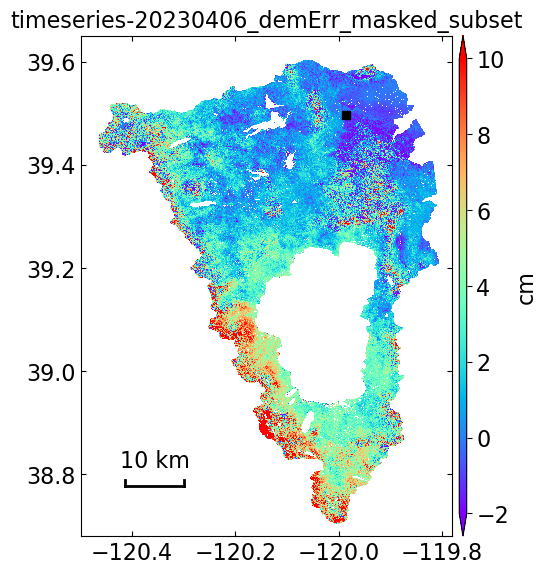

view.py /Users/havazli/snowsar/LIDAR_notebooks/outputs/resampled_ASO_Truckee_2023Apr09_snowdepth_3m-006_subset.tif --sub-lat 38.68 39.65 --sub-lon -120.5 -119.78 -v 0 5 -c rainbow --noreference --noverbose


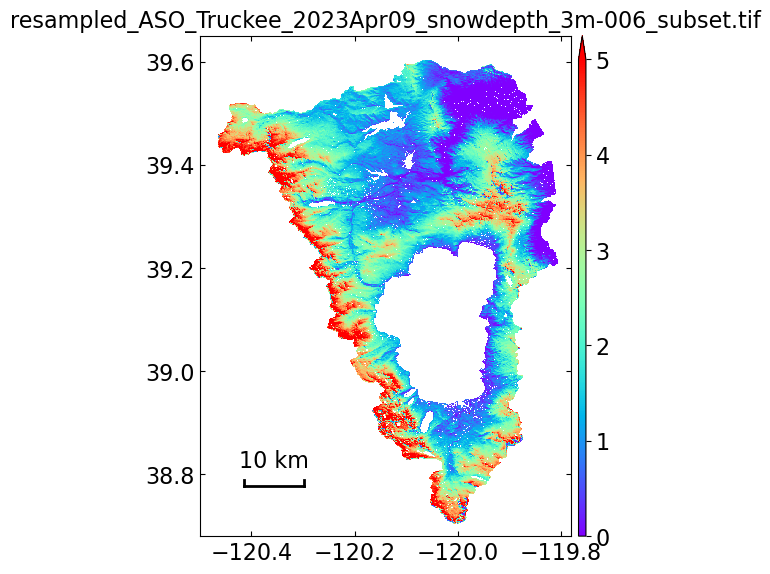

In [30]:
view.main([
    str(SUBSET_TIMESERIES_FILE), TARGET_DATE,
    "--sub-lat", str(SUBSET_LAT[0]), str(SUBSET_LAT[1]),
    "--sub-lon", str(SUBSET_LON[0]), str(SUBSET_LON[1]),
    "-v", "-2", "10",
    "--noverbose",
    "-c", "rainbow",
    "--math", "reverse",
    # "--nodisplay"
])

view.main([
    str(SUBSET_LIDAR_FILE),
    "--sub-lat", str(SUBSET_LAT[0]), str(SUBSET_LAT[1]),
    "--sub-lon", str(SUBSET_LON[0]), str(SUBSET_LON[1]),
    "-v", "0", "5",
    # "-u", "m",
    "-c", "rainbow",
    "--noreference",
    "--noverbose",
    # "--nodisplay"
])


## Correlation analysis with LOS-projected LIDAR

In [18]:
def calculate_swe(ts_arr, inc_angle):
    # ki = 2*pi/wvl # Just for calculating the ambiguity
    F = (-0.6784*inc_angle**2)+(0.2899*inc_angle)-0.8473
    return ts_arr/-F

In [16]:
target_dataset = f"timeseries-{TARGET_DATE}"
ts_data, _ = ut.readfile.read(SUBSET_TIMESERIES_FILE, datasetName=target_dataset)

target_result = compute_pearson_correlation(
    lidar_los["projected_los"],
    ts_data * DISPLACEMENT_SCALE_CM,
    on_invalid="nan",
)
pd.DataFrame([{"dataset": target_dataset, **target_result}])


,dataset,count,statistic,pvalue,valid,reason
0,timeseries-20230406,509583,-0.462529,0.0,True,


In [22]:
ts_data_swe = calculate_swe(-ts_data, incidence_on_lidar_grid)
target_result_swe = compute_pearson_correlation(
    lidar_los["projected_los"],
    ts_data_swe * DISPLACEMENT_SCALE_CM,
    on_invalid="nan",
)
pd.DataFrame([{"dataset": target_dataset, **target_result_swe}])

,dataset,count,statistic,pvalue,valid,reason
0,timeseries-20230406,509583,-0.472234,0.0,True,


In [11]:
slice_names = mintpy_date_slice_names(SUBSET_TIMESERIES_FILE)
slice_dates = [mintpy_date_from_slice_name(name) for name in slice_names]
ts_stack = [ut.readfile.read(SUBSET_TIMESERIES_FILE, datasetName=name)[0] for name in slice_names]
ts_stack = np.stack(ts_stack)

cumulative_ts = cumulative_sum_through_date(ts_stack, slice_dates, CUMULATIVE_END_DATE)
cumulative_result = compute_pearson_correlation(
    lidar_los["projected_los"],
    cumulative_ts * DISPLACEMENT_SCALE_CM,
    on_invalid="nan",
)
pd.DataFrame([{"dataset": f"through_{CUMULATIVE_END_DATE}", **cumulative_result}])


,dataset,count,statistic,pvalue,valid,reason
0,through_20230406,509583,0.202395,0.0,True,


In [12]:
rows = []
for slice_name in slice_names:
    ts_slice, _ = ut.readfile.read(SUBSET_TIMESERIES_FILE, datasetName=slice_name)
    result = compute_pearson_correlation(
        lidar_los["projected_los"],
        ts_slice * DISPLACEMENT_SCALE_CM,
        on_invalid="nan",
    )
    rows.append({"dataset": slice_name, "date": mintpy_date_from_slice_name(slice_name), **result})

pd.DataFrame(rows).sort_values("date").reset_index(drop=True)


,dataset,date,count,statistic,pvalue,valid,reason
0,timeseries-20221215,20221215,509583,0.282695,0.0,True,
1,timeseries-20221229,20221229,509583,0.064535,0.0,True,
2,timeseries-20230112,20230112,509583,0.162856,0.0,True,
3,timeseries-20230126,20230126,509583,0.308982,0.0,True,
4,timeseries-20230209,20230209,509583,0.020399,0.0,True,
5,timeseries-20230223,20230223,509583,0.421382,0.0,True,
6,timeseries-20230309,20230309,509583,0.096073,0.0,True,
7,timeseries-20230323,20230323,509583,-0.067413,0.0,True,
8,timeseries-20230406,20230406,509583,-0.462529,0.0,True,
9,timeseries-20230504,20230504,509583,0.113293,0.0,True,
